In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [7]:
%pwd

'd:\\Streamlit project\\models'

In [2]:
df=pd.read_csv('../data/global_ai_jobs.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000 non-null  object 
 14  weekly_hours          

In [3]:
df.drop('id',axis=1,inplace=True)


In [8]:
df_2026=df[df['year']==2026]
df_2026.groupby('country')['job_openings'].sum().sort_values()


country
Japan          18185
UK             18400
India          18766
USA            18838
France         18906
Brazil         19008
Singapore      19042
Netherlands    19268
Canada         19318
Germany        19343
UAE            19723
Australia      20058
Name: job_openings, dtype: int64

In [10]:
# Missing Values check
missing_values=df.isnull().sum()
if missing_values.sum() > 0:
   display(missing_values[missing_values>0])
else:
   print('No missing values')

No missing values


In [ ]:
# Categorical cols
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical Columns:\n{categorical_cols}')

Categorical Columns:
['country', 'job_role', 'ai_specialization', 'experience_level', 'education_required', 'industry', 'company_size', 'work_mode']


In [ ]:
# top 5 category in each col
for col in categorical_cols:
    print(f'-----TOP 5 category in {col}------\n')
    print(df[col].value_counts().head(5))
    print('='*60)
    print('\n')

-----TOP 5 category in country------

country
Canada       7602
Australia    7589
Singapore    7583
Brazil       7545
UK           7532
Name: count, dtype: int64


-----TOP 5 category in job_role------

job_role
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Name: count, dtype: int64


-----TOP 5 category in ai_specialization------

ai_specialization
Computer Vision           11487
LLM                       11466
Reinforcement Learning    11261
Analytics                 11258
Generative AI             11208
Name: count, dtype: int64


-----TOP 5 category in experience_level------

experience_level
Senior    22680
Lead      22556
Mid       22459
Entry     22305
Name: count, dtype: int64


-----TOP 5 category in education_required------

education_required
Bootcamp    18148
PhD         18070
Bachelor    18005
Diploma     17914
Master      17863
Name: count, dtyp

### **Insights**
* **Uniform Distribution**
* **No class impalance**






In [ ]:
numerical_cols=df.select_dtypes(include=['int','float']).columns.tolist()
print(f'Numerical Columns:\n{numerical_cols}')

Numerical Columns:
['experience_years', 'salary_usd', 'bonus_usd', 'interview_rounds', 'year', 'weekly_hours', 'company_rating', 'job_openings', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'company_funding_billion', 'economic_index', 'ai_maturity_years', 'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'salary_percentile', 'cost_of_living_index', 'employee_satisfaction']


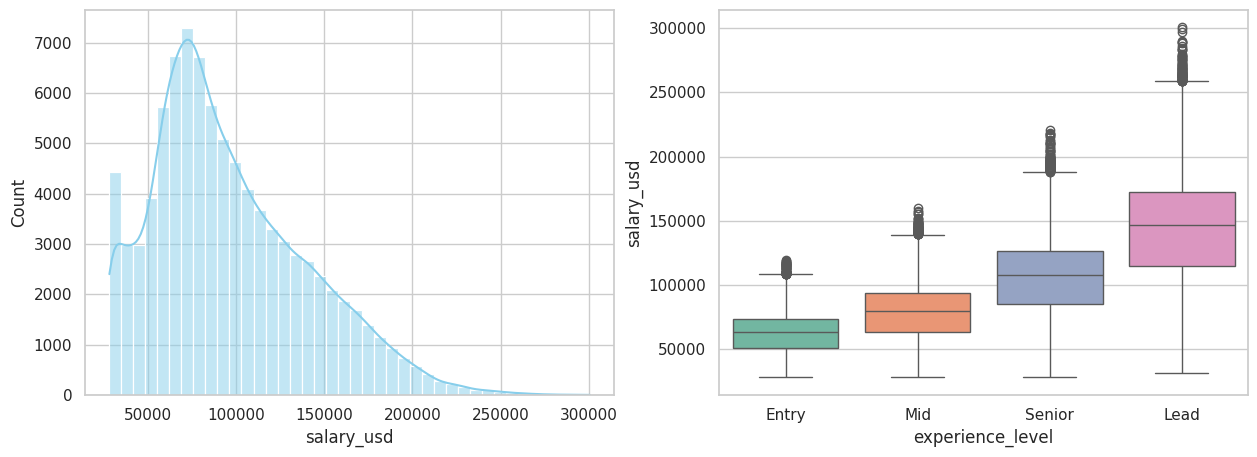

In [ ]:
#visualization of the target variable
fig,axis=plt.subplots(1,2,figsize=(15,5))
sns.histplot(df['salary_usd'],color='skyblue',bins=40,ax=axis[0],kde=True)
order=['Entry','Mid','Senior','Lead']
sns.boxplot(x='experience_level',y='salary_usd',data=df,order=order,ax=axis[1],palette='Set2')
plt.show()



**Right skewed in salary**

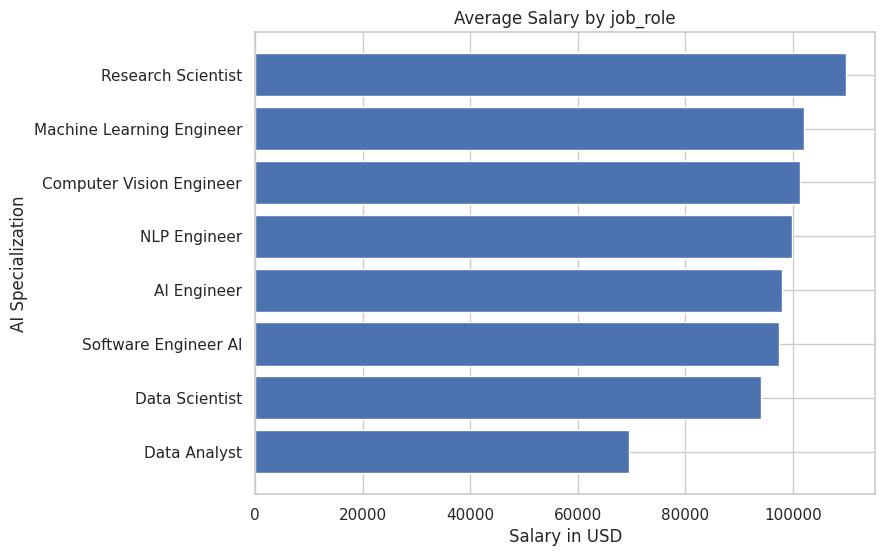

In [ ]:
data=df.groupby('job_role').agg({'salary_usd':'mean'}).sort_values('salary_usd', ascending=True)
plt.figure(figsize=(8,6))
plt.barh(data.index,data.salary_usd)
plt.xlabel('Salary in USD')
plt.ylabel('AI Specialization')
plt.title('Average Salary by job_role')
plt.show()

Text(0.5, 1.0, 'Number of AI Jobs by Industry')

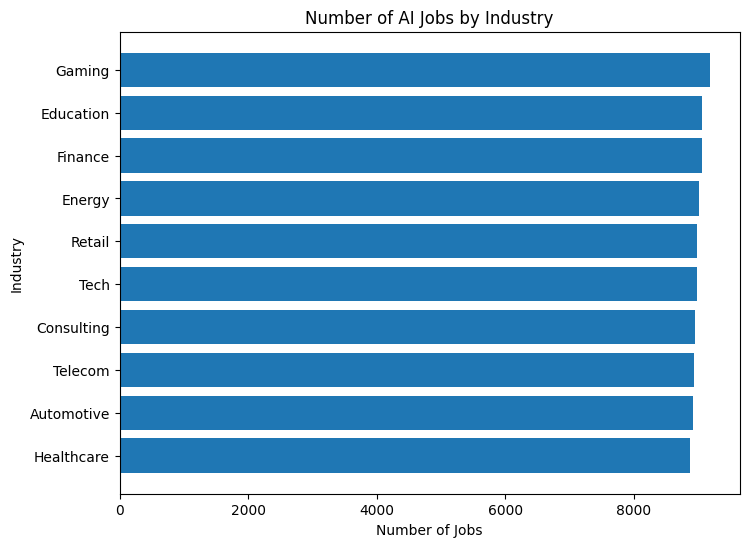

In [ ]:
industries=df['industry'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(8,6))
plt.barh(industries.index,industries.values)
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.title('Number of AI Jobs by Industry')


Text(0, 0.5, 'Number of Jobs')

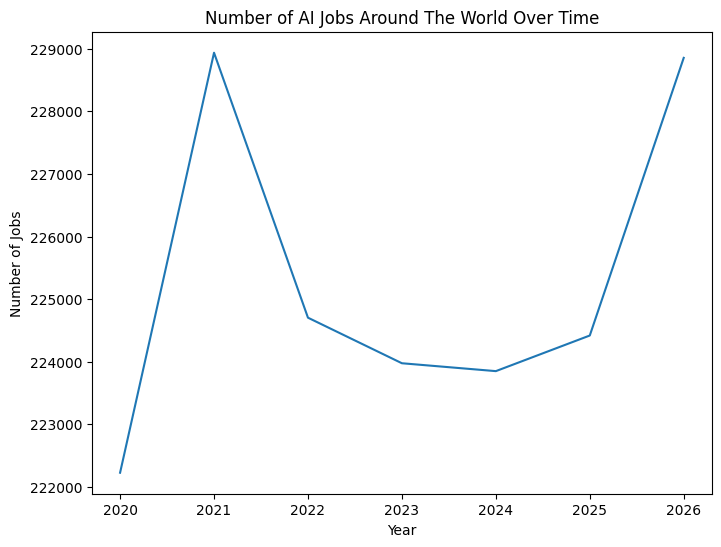

In [ ]:
jobs=df.groupby('year').agg({'job_openings':'sum'}).sort_values('year',ascending=True)
plt.figure(figsize=(8,6))
plt.plot(jobs.index,jobs.job_openings)
plt.title('Number of AI Jobs Around The World Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Jobs')

Text(0.5, 1.0, 'Layoff Risk Over Time')

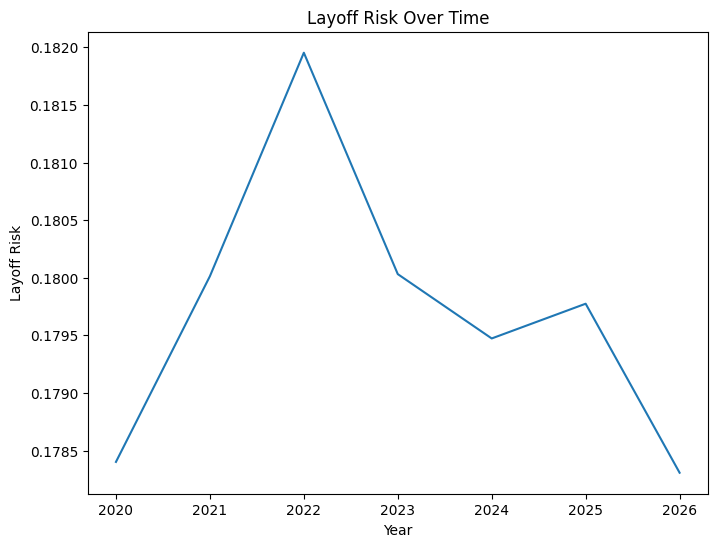

In [ ]:
LayoffRisk=df.groupby('year').agg({'layoff_risk':'mean'}).sort_values('year',ascending=True)
plt.figure(figsize=(8,6))
plt.plot(LayoffRisk.index,LayoffRisk.layoff_risk)
plt.xlabel('Year')
plt.ylabel('Layoff Risk')
plt.title('Layoff Risk Over Time')


Text(0.5, 1.0, 'Average Annual Salary by Country')

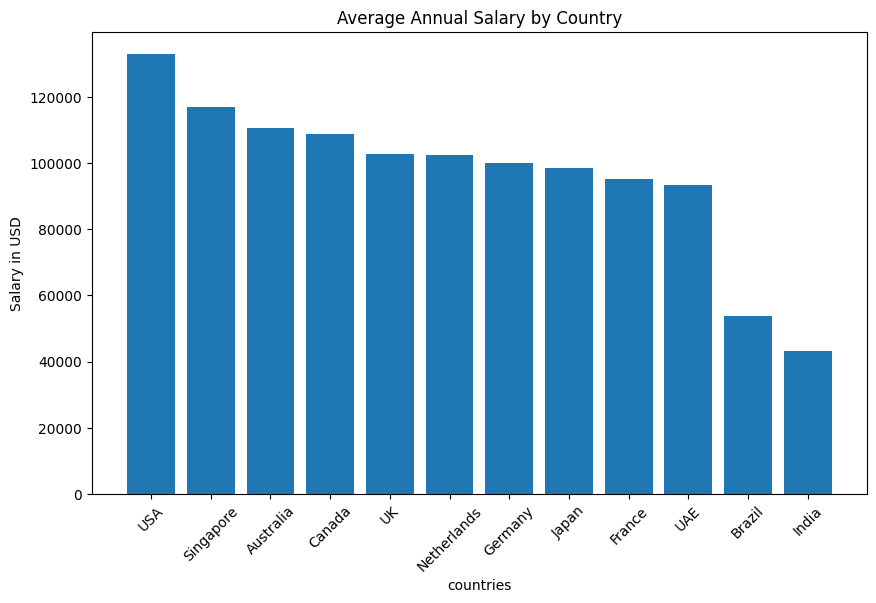

In [ ]:
countries=df.groupby('country').agg({'salary_usd':'mean'}).sort_values('salary_usd',ascending=False)
plt.figure(figsize=(10,6))
plt.bar(countries.index,countries.salary_usd)
plt.xlabel('countries')
plt.ylabel('Salary in USD')
plt.xticks(rotation=45)
plt.title('Average Annual Salary by Country')


Text(0.5, 1.0, 'Leading Countries in AI Job Hiring (Top 10)')

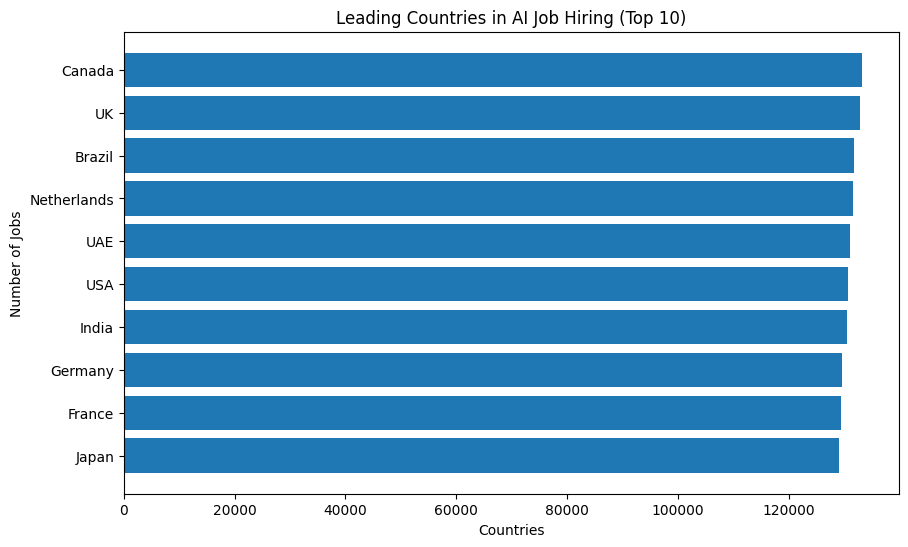

In [ ]:
cuntries_jobs=df.groupby('country').agg({'job_openings':'sum'}).sort_values('job_openings').head(10)
plt.figure(figsize=(10,6))
plt.barh(cuntries_jobs.index,cuntries_jobs.job_openings)
plt.xlabel('Countries')
plt.ylabel('Number of Jobs')
plt.title('Leading Countries in AI Job Hiring (Top 10)')

# Data Preprocessing

## Normalization for Numrical cols

In [ ]:
standard_scaler=StandardScaler()
df[numerical_cols]=standard_scaler.fit_transform(df[numerical_cols])
df[numerical_cols].head(5)

,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,-1.193374,-0.684673,-0.967886,1.469197,-1.499641,-0.141772,-0.710103,-0.958379,-0.126429,1.707338,...,1.155540,-1.332976,0.888958,-1.640407,0.604757,0.291626,-1.271880,0.154288,-0.473665,0.402131
1,-1.023575,-0.478870,-0.166790,-0.877472,-1.000293,0.625286,0.567199,1.207631,-0.106921,1.577933,...,1.155540,0.122647,-0.740411,-0.580001,0.217165,-1.373285,-1.271880,0.258125,-1.098183,-0.705702
2,-1.193374,-1.249254,-0.983989,-0.877472,-1.499641,0.241757,1.692957,-0.958379,1.193578,1.791071,...,-1.151048,-1.332976,-0.047063,-0.491634,0.139646,-0.086763,-0.078117,-1.299432,1.087627,-1.444256
3,-0.174577,-1.212654,-0.640752,-1.464139,1.496445,1.227974,0.740393,0.697982,0.240853,-0.492550,...,1.649809,1.023746,-0.116397,0.303671,0.604757,-1.070574,0.410240,0.811923,-0.022625,-2.059719
4,-1.193374,-0.624265,-1.048655,-1.464139,-1.000293,0.223494,1.065131,-0.066492,0.964873,0.999415,...,0.661271,1.093061,-0.116397,-1.021837,-0.402983,-0.011085,-1.163356,-1.022533,-1.098183,-0.090239


### Ordinal Data Encoding

In [ ]:
mapping_experince={'Entry':0,'Mid':1,'Senior':2,'Lead':3}
df['experince_level']=df['experience_level'].map(mapping_experince)
df['experince_level'].head(5)

,experince_level
0,0
1,0
2,0
3,2
4,0


### One Hot Encoding for Nominal Data

In [ ]:
#one hot encoding for nominal catogerioes
nominal_categories=categorical_cols.remove('experience_level')
df=pd.get_dummies(df,columns=nominal_categories,drop_first=True)
df.shape


(90000, 74)

# Linear Regression

In [ ]:
x=df.drop('salary_usd',axis=1)
y=df['salary_usd']
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
model=LinearRegression()
model.fit(x_train,y_train)
ypred=model.predict(x_test)
R2=r2_score(y_test,ypred)
MSE=mean_squared_error(y_test,ypred)
MAE=mean_absolute_error(y_test,ypred)
print(f'Mean Abslute Error: {MAE}')
print(f'Mean Squared Error: {MSE}')
print(f'R2 Score: {R2}')


Mean Abslute Error: 0.2393039681318325
Mean Squared Error: 0.09480480074471716
R2 Score: 0.9047389723674849


## **Boxblot visualization for columns with outkliers only**

In [ ]:
def removing_outliers(df):
  features=df.select_dtypes(include=['int','float']).columns
  result={}
  for feature in features:
    Q1=df[feature].quantile(0.25)
    Q3=df[feature].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*(IQR)
    upper_limit=Q3+1.5*(IQR)
    count=((df[feature]<lower_limit)|(df[feature]>upper_limit)).sum()
    df=df[feature].clip(lower_limit,upper_limit)
    result[feature]=count
  return df,result
